In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from scipy.stats import zscore

# 1. Carregando os dados
housing = fetch_california_housing(as_frame=True)
df = housing.frame

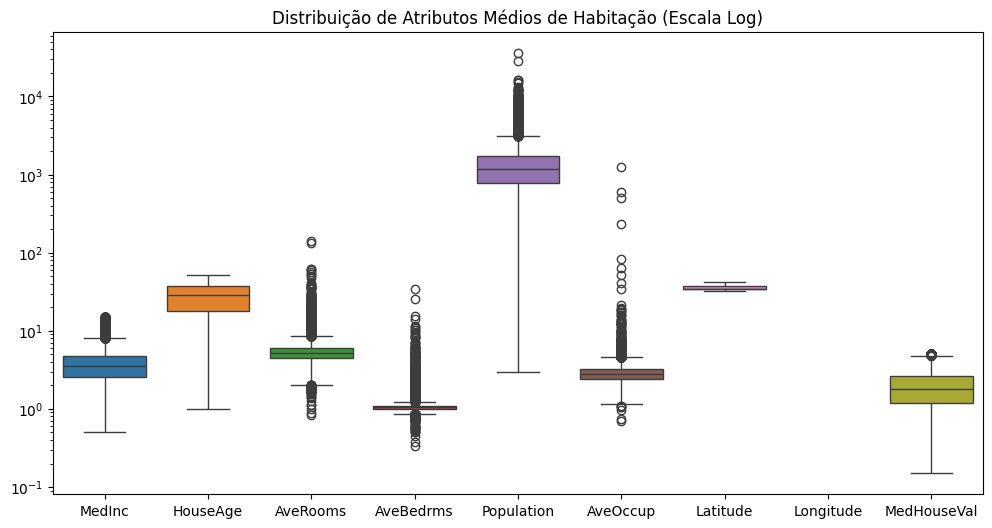

In [41]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.yscale('log') # Escala logarítmica para visualizar discrepâncias massivas
plt.title('Distribuição de Atributos Médios de Habitação (Escala Log)')
plt.show()

In [42]:
# 2. Detecção Univariada: Z-Score e IQR
# Vamos focar na variável 'MedInc' (Renda Mediana)
target_col = 'MedInc'

df['z_score'] = zscore(df[target_col])
outliers_z = df[abs(df['z_score']) > 3]

q1 = df[target_col].quantile(0.25)
q3 = df[target_col].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_iqr = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]

print(f"Outliers detectados (Z-score): {len(outliers_z)}")
print(f"Outliers detectados (IQR): {len(outliers_iqr)}")


Outliers detectados (Z-score): 345
Outliers detectados (IQR): 681


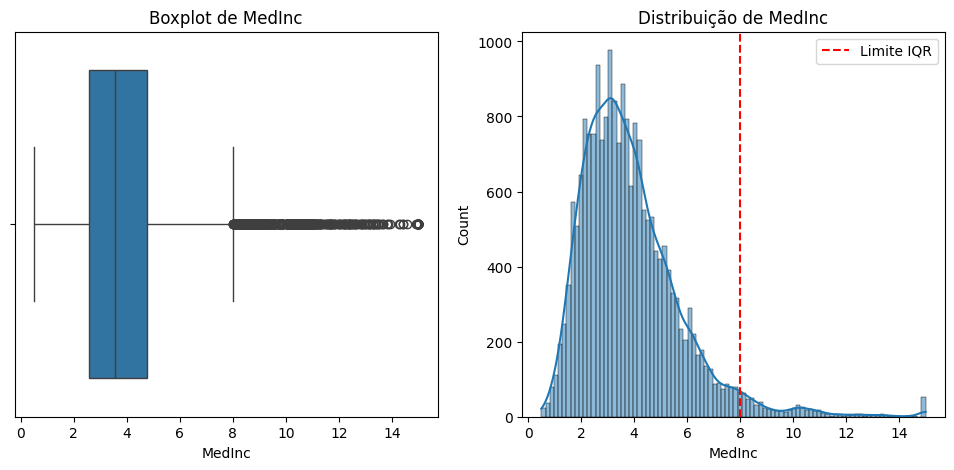

In [43]:
# 3. Visualização com Matplotlib e Seaborn
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df[target_col])
plt.title(f"Boxplot de {target_col}")

plt.subplot(1, 2, 2)
sns.histplot(df[target_col], kde=True)
plt.axvline(upper_bound, color='r', linestyle='--', label='Limite IQR')
plt.title(f"Distribuição de {target_col}")
plt.legend()
plt.show()

### Detecção Avançada Multivariada: Isolation Forest vs Local Outlier Factor

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

features = ['MedInc', 'AveOccup']
X = df[features]

# DICA Do TIO: LOF é baseado em distância (KNN), então escalar é MANDATÓRIO.
# O Isolation Forest é baseado em árvores e lida melhor com escalas diferentes,
# mas vamos escalar para uma comparação justa.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [45]:
# 2. Configuração dos Modelos
# Vamos assumir uma taxa de contaminação de 2% para ambos
contamination_rate = 0.02

# Isolation Forest (Abordagem Global)
iforest = IsolationForest(contamination=contamination_rate, random_state=42)
df['if_outlier'] = iforest.fit_predict(X_scaled)

# Local Outlier Factor (Abordagem Local de Densidade)
# n_neighbors=20 é o padrão, mas pode ser tunado
lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination_rate)
df['lof_outlier'] = lof.fit_predict(X_scaled)

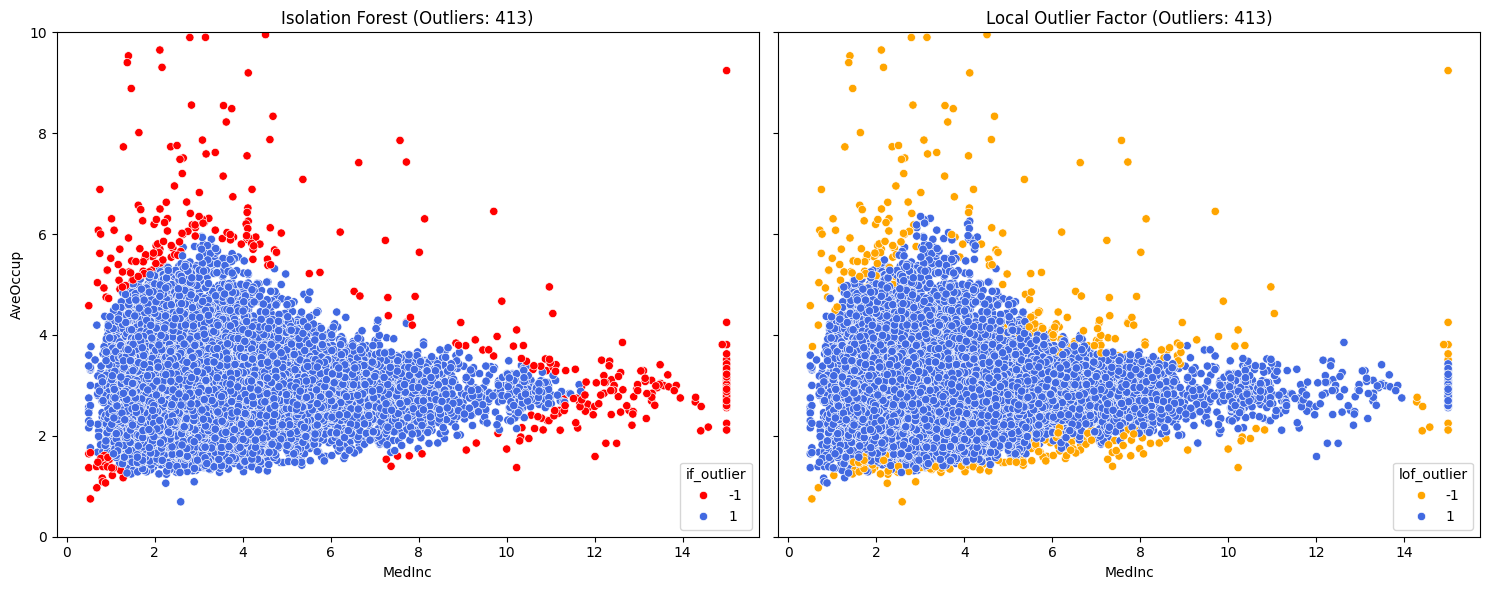

In [46]:
# 3. Visualização Comparativa
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot Isolation Forest
sns.scatterplot(data=df, x='MedInc', y='AveOccup', hue='if_outlier',
                palette={1: 'royalblue', -1: 'red'}, ax=axes[0])
axes[0].set_title(f'Isolation Forest (Outliers: {len(df[df.if_outlier==-1])})')
axes[0].set_ylim(0, 10) # Limite para visualizar a massa de dados

# Plot Local Outlier Factor
sns.scatterplot(data=df, x='MedInc', y='AveOccup', hue='lof_outlier',
                palette={1: 'royalblue', -1: 'orange'}, ax=axes[1])
axes[1].set_title(f'Local Outlier Factor (Outliers: {len(df[df.lof_outlier==-1])})')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

## Bônus: Outliers em Texto

In [ ]:
from sentence_transformers import SentenceTransformer, util

# 1. Inicializa o modelo (MiniLM é eficiente e preciso para similaridade)
model = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
# 2. Corpus de referência (Contexto: Gastronomia/Restaurante)
corpus = [
    "A comida estava excelente e o atendimento foi rápido.",
    "O ambiente é muito aconchegante, adorei a massa.",
    "Melhor risoto que já comi na vida!",
    "Preço justo e ingredientes de alta qualidade.",
    "O garçom foi muito atencioso durante todo o jantar."
]

# 3. Frases para teste
test_sentences = [
    "O tempero do peixe estava no ponto certo.", # Normal
    "Erro crítico no servidor: stack trace de memória insuficiente no banco de dados.", # Outlier Semântico
    "A política monetária do Banco Central impacta o câmbio." # Outlier Semântico
]

In [47]:
# 4. Processo de Detecção
corpus_embeddings = model.encode(corpus)
mean_embedding = np.mean(corpus_embeddings, axis=0)

# Ajustando o limiar para ser mais rigoroso e detectar os outliers corretamente
threshold = 0.55

print(f"--- Analisando Outliers Semânticos (Limiar: {threshold}) ---\n")

for sentence in test_sentences:
    test_embedding = model.encode(sentence)

    # Calculamos a similaridade de cosseno
    similarity = util.cos_sim(test_embedding, mean_embedding).item()

    status = "Normal" if similarity > threshold else "Outlier Semântico"
    print(f"Sentença: '{sentence}'")
    print(f"Similaridade Semântica: {similarity:.4f} -> Status: {status}\n")

--- Analisando Outliers Semânticos (Limiar: 0.55) ---

Sentença: 'O tempero do peixe estava no ponto certo.'
Similaridade Semântica: 0.5700 -> Status: Normal

Sentença: 'Erro crítico no servidor: stack trace de memória insuficiente no banco de dados.'
Similaridade Semântica: 0.4661 -> Status: Outlier Semântico

Sentença: 'A política monetária do Banco Central impacta o câmbio.'
Similaridade Semântica: 0.4670 -> Status: Outlier Semântico

